In [ ]:
#1 import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [ ]:
#2 dataset loading

data=fetch_california_housing(as_frame=True)
df=data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


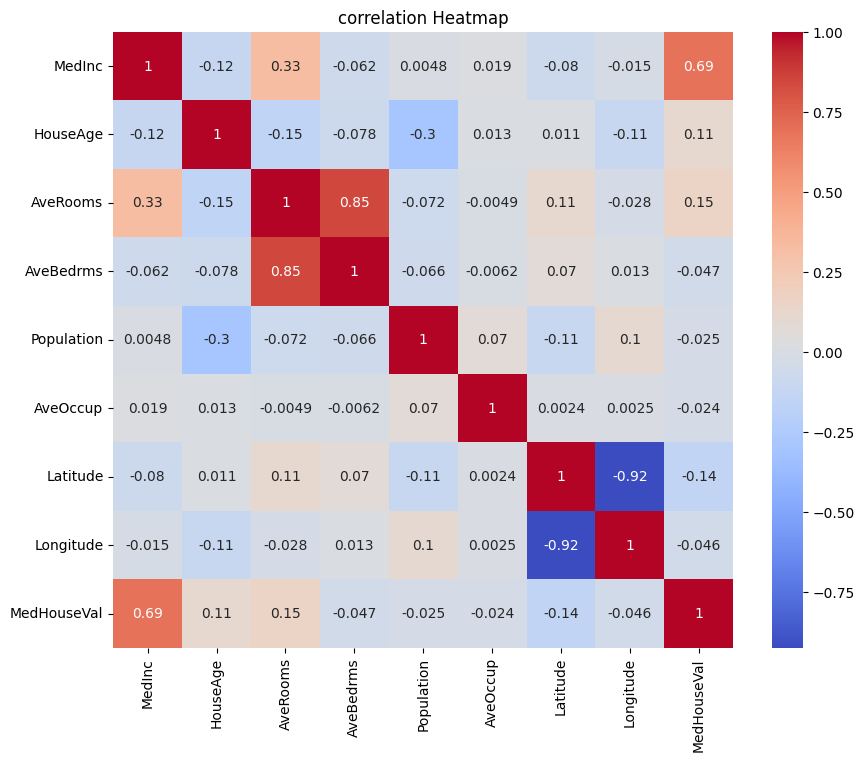

In [ ]:
#3 feature selection
features = [col for col in df.columns if col != 'MedHouseVal']
plt.figure(figsize=(10,8))
sns.heatmap(df[features+["MedHouseVal"]].corr(),annot=True, cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

In [ ]:
#4. feature sselection with variance inflation fact

vif_data=pd.DataFrame()
vif_data["Feature"]=features
vif_data["VIF"]=[variance_inflation_factor(df[features].values,i) for i in range(df[features].shape[1])]
vif_data

,Feature,VIF
0,MedInc,11.511140
1,HouseAge,7.195917
2,AveRooms,45.993601
3,AveBedrms,43.590314
4,Population,2.935745
5,AveOccup,1.095243
6,Latitude,559.874071
7,Longitude,633.711654


In [ ]:
#5 train test split
X = df[features]
y = df['MedHouseVal']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [ ]:
#6. train linear regression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
#7 Predictions
y_pred_lr=lr.predict(X_test)

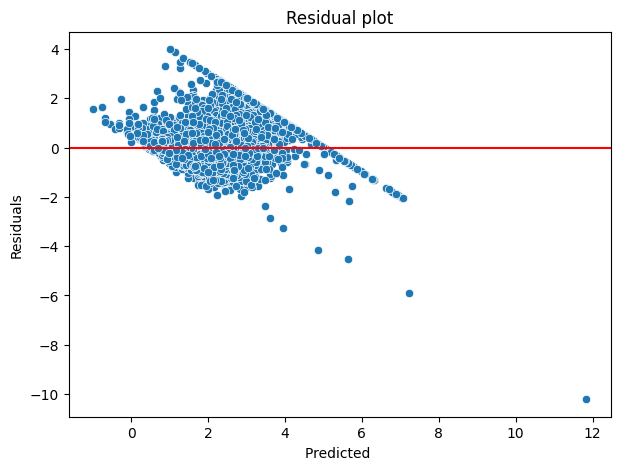

In [ ]:
#8 visualization regression residuals

residuals=y_test-y_pred_lr
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_lr,y=residuals)
plt.axhline(y=0,color="red")
plt.xlabel("Predicted ")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

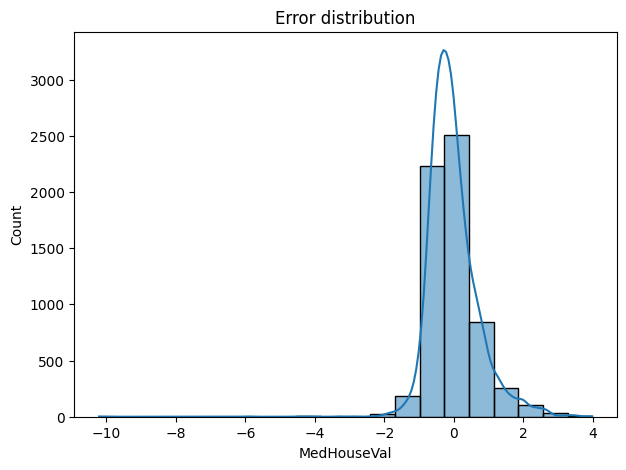

In [ ]:
#9 error distribution
plt.figure(figsize=(7,5))
sns.histplot(residuals,bins=20,kde=True)
plt.title("Error distribution")
plt.show()

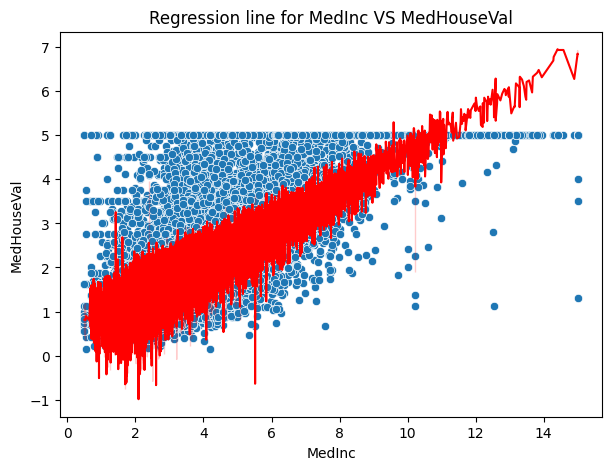

In [ ]:
#10 regression line for 1 feature
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["MedInc"],y=df["MedHouseVal"])
sns.lineplot(x=df["MedInc"],y=lr.predict(df[features]),color="red")
plt.title("Regression line for MedInc VS MedHouseVal")
plt.show()


In [ ]:
#11 train decision tree regressor
dt=DecisionTreeRegressor(max_depth=6,random_state=42)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)

In [ ]:
#12 SVR
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)
svr=SVR(kernel='rbf',C=100, epsilon=0.1)
svr.fit(x_train_scaled,y_train)
y_pred_svr=svr.predict(x_test_scaled)

In [ ]:
#13 evaluation
def evaluation(y_true,y_pred,X_test):
    mae=mean_absolute_error(y_true,y_pred)
    mse=mean_squared_error(y_true,y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_true,y_pred)
    adj_r2=1-(1-r2)*(len(y_true)-1)/(len(y_true)-X_test.shape[1]-1)
    return mae,mse,rmse,r2,adj_r2
